 # Pima Indians Diabetes Dataset

## Description

This dataset was originally collected by the National Institute of Diabetes and Digestive and Kidney Diseases in the United States. The purpose of the dataset is to predict whether a patient has diabetes or not based on certain medical measurements. All patients in this dataset are females, at least 21 years old and of Pima Indian heritage — a Native American population that has one of the highest rates of diabetes in the world.

## Column Description

**pregnancy** - This record shows how many times a patient has been pregnant, having multiple pregnacy can develop type2 diabetics.

**Glucose** - This indicate the level of glucose to be a dibetic patient(Normal glucose → below 140 mg/dL, Pre-diabetic → 140 to 199 mg/dL, Diabetic → 200 mg/dL and above)

**BloodPressure** - This is the diastolic blood pressure measured in millimetres of mercury (mm Hg). Normal blood pressure → below 80 mm Hg, High blood pressure → 80 mm Hg and above.

**SkinThickness** - This measures the thickness of the triceps skin fold in millimetres.

**Insulin** - This records the level of insulin in the blood after 2 hours measured in micro units per millilitre (mu U/ml). Normal insulin  → 16 to 166 mu U/ml, Above 166 → abnormally high — possible insulin resistance.

**BMI** stands for Body Mass Index. It is calculated from a person's weight and height:BMI = weight (kg) / height (m)²

**DiabetesPedigreeFunction** - This is a score that measures how likely a person is to get diabetes based on their family history, Higher score → stronger family history of diabetes → higher risk, Lower score  → weaker family history → lower risk

**Age** - This is the age of the patient in years.

**Outcome** - This is the target column — the answer your model is trying to predict

## Problem Solved

The problem to solved is, based on the patient medical measurement which is the columns does the patient has diabetics or not because of that i choose outcome to be my target because it has the answer yes=1, No=0, all other column are feature column that will help me predict the answer.

In [1]:
#import your librabies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report  
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(sklearn.__version__)

1.8.0


In [3]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
#load your data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"

columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigree','Age','Outcome']

df = pd.read_csv(url, names=columns)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pregnancies       768 non-null    int64  
 1   Glucose           768 non-null    int64  
 2   BloodPressure     768 non-null    int64  
 3   SkinThickness     768 non-null    int64  
 4   Insulin           768 non-null    int64  
 5   BMI               768 non-null    float64
 6   DiabetesPedigree  768 non-null    float64
 7   Age               768 non-null    int64  
 8   Outcome           768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigree,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [7]:
df.isnull().sum()

Pregnancies         0
Glucose             0
BloodPressure       0
SkinThickness       0
Insulin             0
BMI                 0
DiabetesPedigree    0
Age                 0
Outcome             0
dtype: int64

The data was not clean but the missing values were just replaced with zero, I replaced the zero with nan for proper cleaning, since all the minimum numbers are zero except Age

In [8]:
missing_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigree','Age']
df[missing_cols] = df[missing_cols].replace(0, np.nan)

print(df.isnull().sum())

Pregnancies         111
Glucose               5
BloodPressure        35
SkinThickness       227
Insulin             374
BMI                  11
DiabetesPedigree      0
Age                   0
Outcome               0
dtype: int64


Handle Outliers: since we use boxplot to find outlier, i will visualize with boxplot to identify which column has outlier so that i can remove it



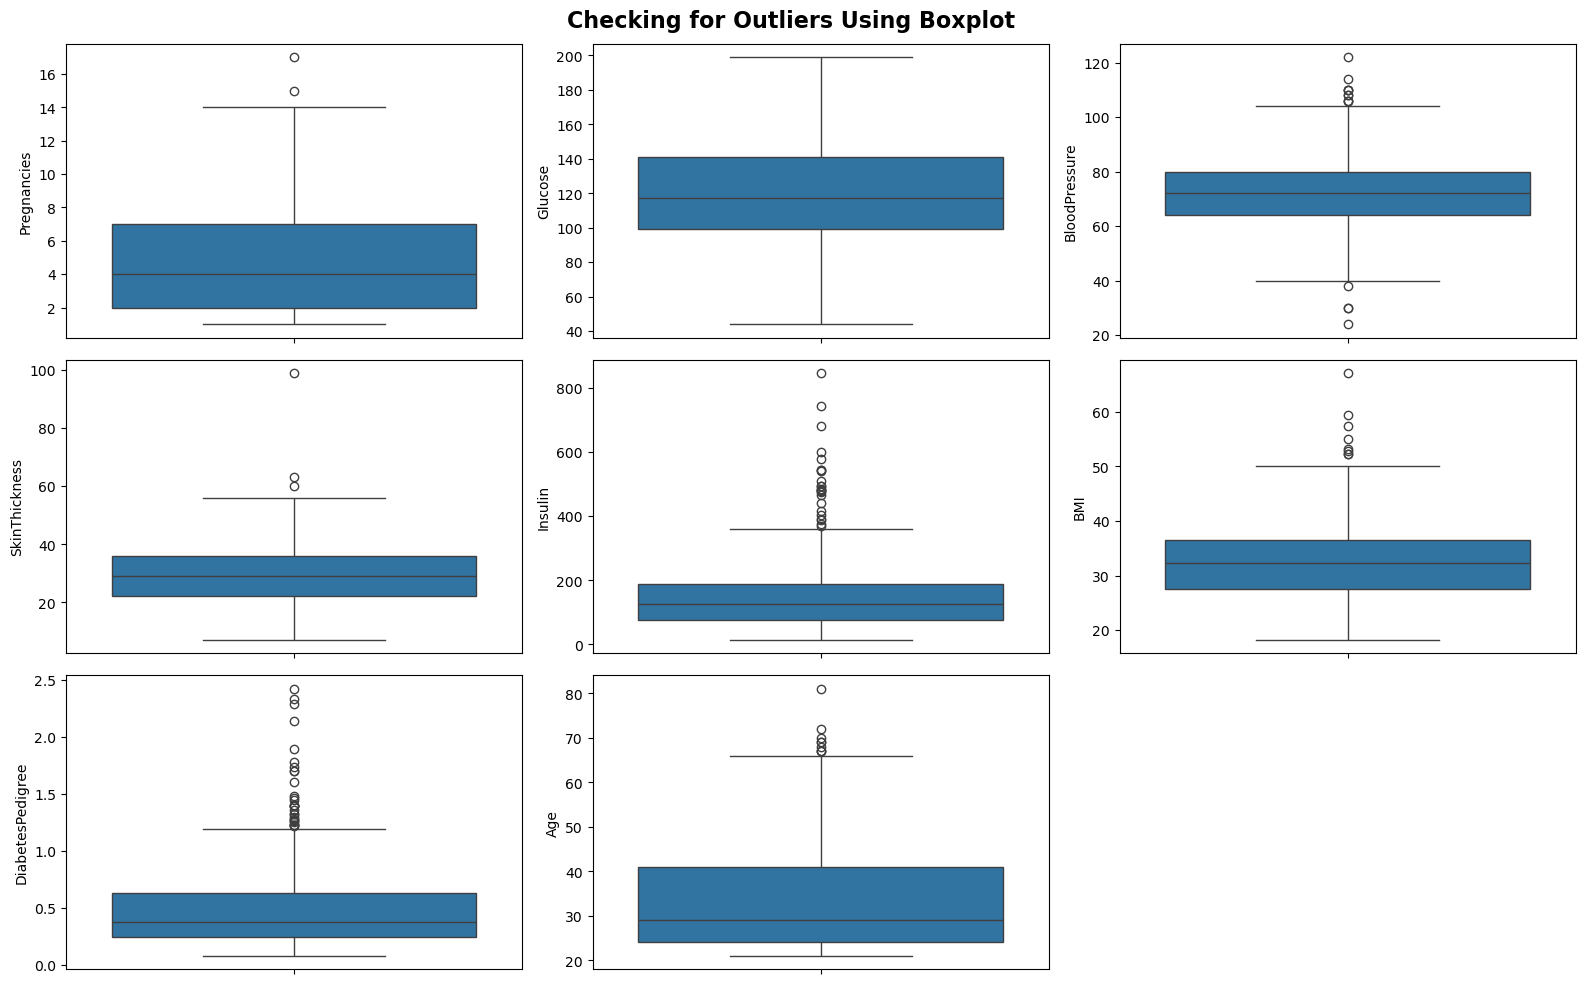

In [9]:
#check for outliers using boxplot
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age']
plt.figure(figsize= (16, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
plt.suptitle('Checking for Outliers Using Boxplot', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
#checking for outliers using IQR to know the exact number 
df_orginal = df.copy()
# Calculate IQR for the columns
for col in cols:
    
    Q1 = df[col].quantile(0.25)   # bottom 25%
    Q3 = df[col].quantile(0.75)   # top 75%
    IQR = Q3 - Q1                 # the middle range
    # Define the boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Find the outliers
    Outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'{col}: {len(Outliers)}')

Pregnancies: 2
Glucose: 0
BloodPressure: 14
SkinThickness: 3
Insulin: 24
BMI: 8
DiabetesPedigree: 29
Age: 9


In [11]:
#filling in missing values after checking for outliers so as to know what to use and fill each column
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].median())
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].mean())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].median())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean()) 
df['Pregnancies'] = df['Pregnancies'].fillna(df['Pregnancies'].mode()[0])

In [12]:
df.isnull().sum()

Pregnancies         0
Glucose             0
BloodPressure       0
SkinThickness       0
Insulin             0
BMI                 0
DiabetesPedigree    0
Age                 0
Outcome             0
dtype: int64

In [13]:
#capping the outliers
for col in cols:
    
    Q1 = df[col].quantile(0.25)   
    Q3 = df[col].quantile(0.75)   
    IQR = Q3 - Q1                 
  
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    #Remove the outliers
    df[col] = df[col].clip(lower_bound, upper_bound)
    print(f'{col}: {len(Outliers)}')
print(f'Final rows remaining after all columns cleaned: {len(df)}')

Pregnancies: 9
Glucose: 9
BloodPressure: 9
SkinThickness: 9
Insulin: 9
BMI: 9
DiabetesPedigree: 9
Age: 9
Final rows remaining after all columns cleaned: 768


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.981771,3.193202,1.000,1.00000,3.00000,6.00000,13.500
Glucose,768.0,121.686763,30.435949,44.000,99.75000,117.00000,140.25000,199.000
BloodPressure,768.0,72.358073,11.697097,40.000,64.00000,72.00000,80.00000,104.000
SkinThickness,768.0,28.911883,7.443497,14.500,25.00000,29.15342,32.00000,42.500
Insulin,768.0,124.691081,7.913595,112.875,121.50000,125.00000,127.25000,135.875
BMI,768.0,32.395615,6.667466,18.200,27.50000,32.40000,36.60000,50.250
DiabetesPedigree,768.0,0.458914,0.285596,0.078,0.24375,0.37250,0.62625,1.200
Age,768.0,33.199870,11.628404,21.000,24.00000,29.00000,41.00000,66.500
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.00000,1.00000,1.000


In [15]:
#since outcome is the target column, let's check how many unique value that we have
counts = df['Outcome'].value_counts()
print(f'Dibetic Patient are: {counts[1]}')
print(f'Non-Dibetic Patient are: {counts[0]}')
print(f'Both dibetic and non-dibetic are: {len(df)}')

Dibetic Patient are: 268
Non-Dibetic Patient are: 500
Both dibetic and non-dibetic are: 768


### EDA OR Data Visualization

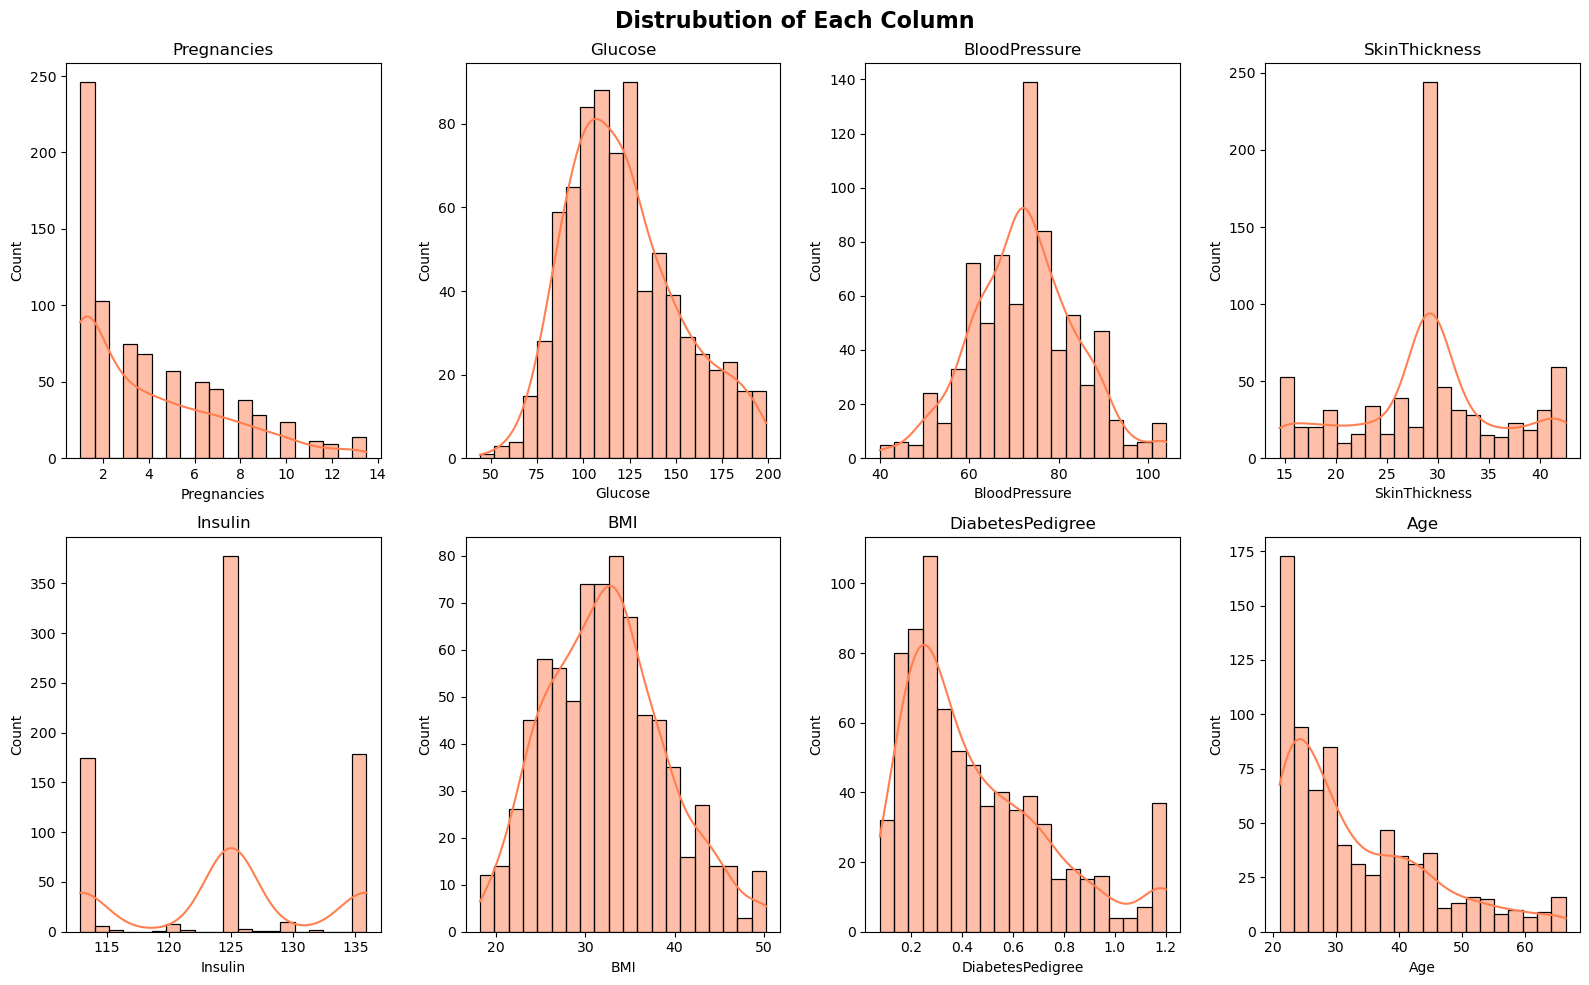

In [16]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(cols, 1):
    plt.subplot(2, 4, i)
    sns.histplot(data=df[col], color='coral', bins=20, kde=True)
    plt.title(col)
plt.suptitle('Distrubution of Each Column', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()   

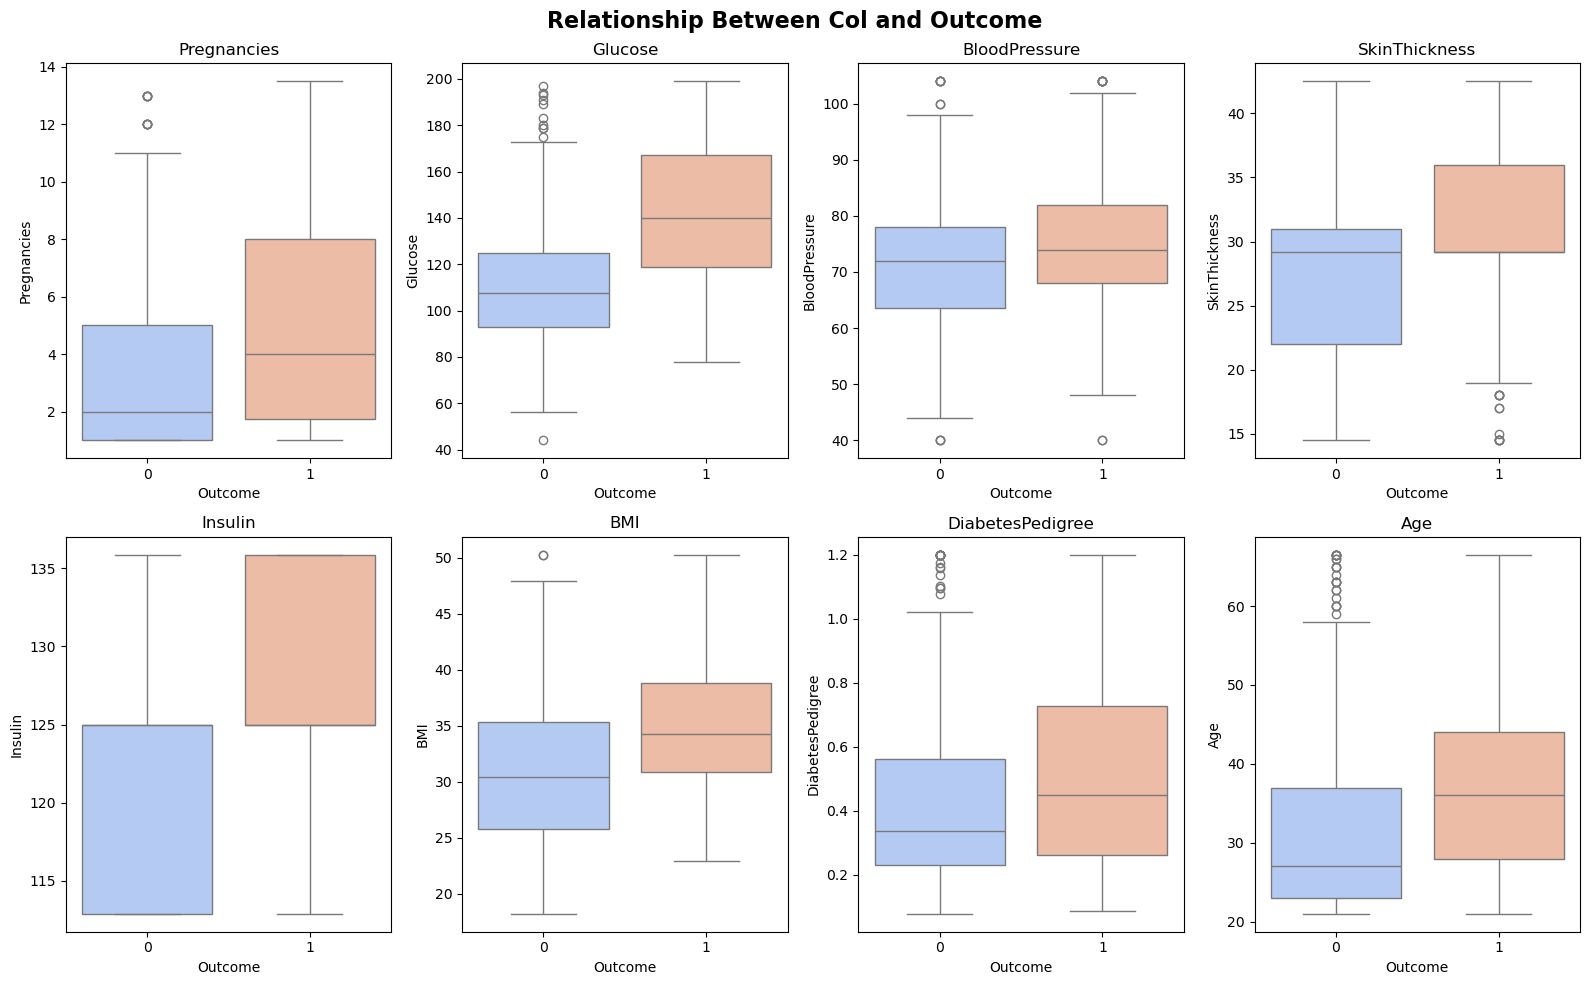

In [17]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(data=df, x='Outcome', y=col,  palette='coolwarm',hue='Outcome',legend=False)
    plt.title(col)
plt.suptitle('Relationship Between Col and Outcome', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()           

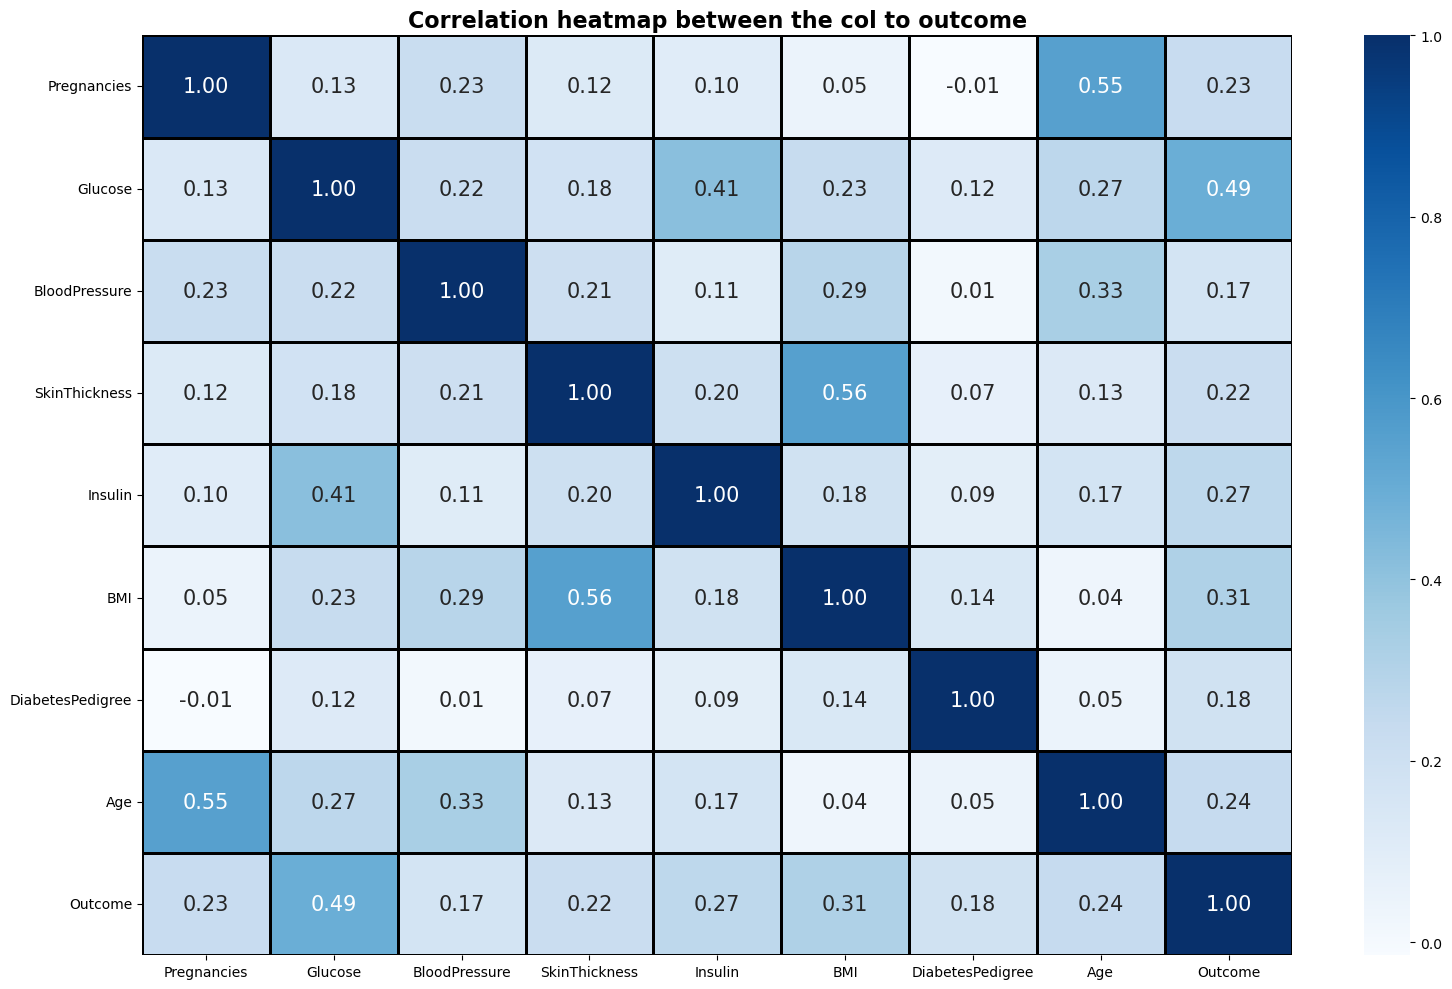

In [18]:
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f', linewidth=1.0, linecolor='black', annot_kws={'size':15})
plt.title('Correlation heatmap between the col to outcome', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

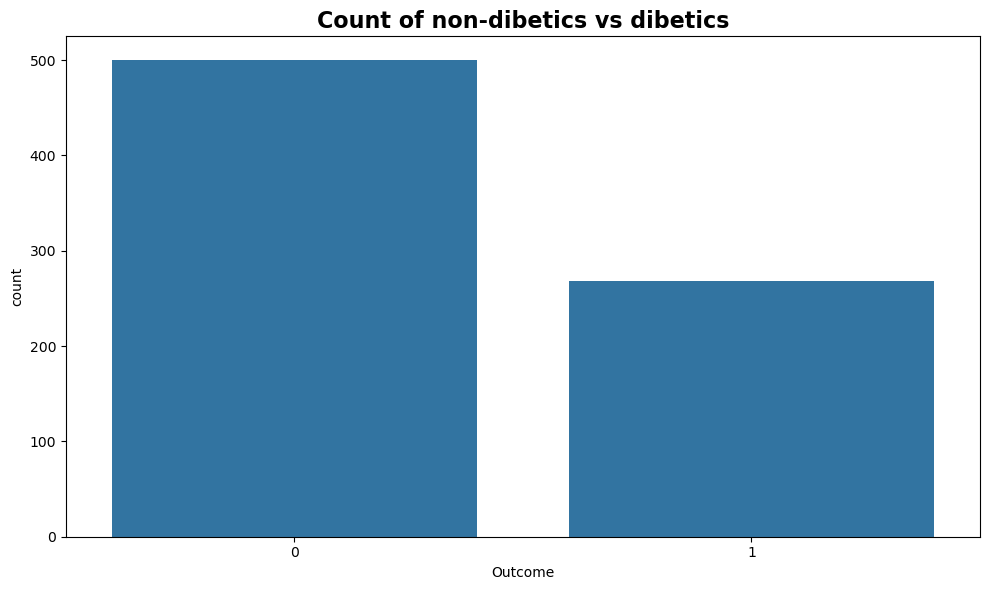

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Outcome', data=df)
plt.title('Count of non-dibetics vs dibetics', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
#using standardscaler to scale it for proper model building
scaler = StandardScaler()
col_to_scale =  ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age']
df[col_to_scale] = scaler.fit_transform(df[col_to_scale])
df[col_to_scale]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age
0,0.632451,0.865108,-0.030632,0.818444,0.039062,0.180754,0.588927,1.445691
1,-0.934396,-1.206162,-0.543914,0.011846,0.039062,-0.869804,-0.378101,-0.189304
2,1.259190,2.015813,-0.715008,0.032470,0.039062,-1.365068,0.746595,-0.103252
3,-0.934396,-1.074652,-0.543914,-0.794752,-1.494110,-0.644685,-1.022787,-1.049828
4,-0.934396,0.503458,-2.768136,0.818444,1.414175,1.606512,2.596563,-0.017199
...,...,...,...,...,...,...,...,...
763,1.885929,-0.680125,0.311556,1.826691,1.414175,0.075698,-1.008772,2.564372
764,-0.621026,0.010298,-0.201726,-0.257020,0.039062,0.661009,-0.416642,-0.533513
765,0.319082,-0.022579,-0.030632,-0.794752,-1.494110,-0.929836,-0.749497,-0.275356
766,-0.934396,0.141808,-1.057196,0.032470,0.039062,-0.344525,-0.385109,1.187534


In [21]:
#split data ready to train your model
from sklearn.model_selection import train_test_split

X= df[col_to_scale]
y= df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [22]:
#check for the exact number for both of them
Trainingset = X_train
TestingSet = X_test
print(f'Trainingset: {len(Trainingset)}')
print(f'Testingset: {len(TestingSet)}')

Trainingset: 614
Testingset: 154


### Train and evaluate all models

In [23]:
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [24]:
lr_prediction = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_prediction)
lr_f1 = f1_score(y_test, lr_prediction) 
lr_precision = precision_score(y_test, lr_prediction, average='weighted')
lr_recall = recall_score(y_test, lr_prediction, average='weighted')

In [25]:
#since two is the highest max_depth
dt_model = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [26]:
dt_prediction = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_prediction)
dt_f1 = f1_score(y_test, dt_prediction)
dt_precision = precision_score(y_test, dt_prediction, average='weighted')
dt_recall = recall_score(y_test, dt_prediction, average='weighted')

In [27]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [28]:
rf_prediction = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_prediction)
rf_f1 = f1_score(y_test, rf_prediction)
rf_precision = precision_score(y_test, rf_prediction, average='weighted')
rf_recall = recall_score(y_test, rf_prediction, average='weighted')

In [29]:
svm_model = SVC(C = 10, gamma='scale', kernel= 'linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [30]:
svm_prediction =svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_prediction)
svm_f1 = f1_score(y_test, svm_prediction)
svm_precision = precision_score(y_test, svm_prediction, average= 'weighted')
svm_recall = recall_score(y_test, svm_prediction, average='weighted')

In [31]:
Models = {
    'LogisticRegression': lr_f1,
    'DecisionTreeClassifier': dt_f1,
    'RandomForestClassifier': rf_f1,
    'SVC': svm_f1,
}

All the metrics are always calculated from testing dataset

In [32]:
print('='*70)
print('                        MODEL COMPARISION REPORT          ')
print('='*70)
print(f"{'Models':<25} {'Accuracy':>10}  {'Precision':>10} {'Recall':>10} {'f1_score':>10}")
print(f'{"LogisticRegression":<25} {lr_accuracy:>10.2f} {lr_precision:>10.2f} {lr_recall:>10.2f} {lr_f1:>10.2f}')
print(f'{"DecisionTreeClassifier":<25} {dt_accuracy:>10.2f} {dt_precision:>10.2f} {dt_recall:>10.2f} {dt_f1:>10.2f}')
print(f'{"RandomForestClassifier":<25} {rf_accuracy:>10.2f} {rf_precision:>10.2f} {rf_recall:>10.2f} {rf_f1:>10.2f}')
print(f'{"SVC":<25} {svm_accuracy:>10.2f} {svm_precision:>10.2f} {svm_recall:>10.2f} {svm_f1:>10.2f}')

                        MODEL COMPARISION REPORT          
Models                      Accuracy   Precision     Recall   f1_score
LogisticRegression              0.75       0.75       0.75       0.64
DecisionTreeClassifier          0.77       0.77       0.77       0.65
RandomForestClassifier          0.79       0.79       0.79       0.65
SVC                             0.76       0.76       0.76       0.66


In [33]:
best_model = max(Models, key=Models.get)
print(f'The best_model is {best_model} with the f1_score of {Models[best_model]*100:.2f}%')

The best_model is SVC with the f1_score of 66.06%


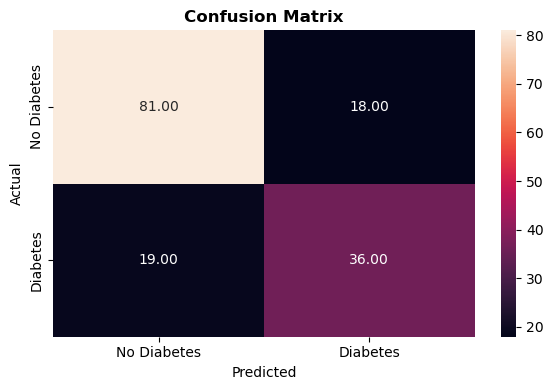

In [34]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, svm_prediction)
sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Using Hyperparmeter Tuning

In [35]:
# using hyperparmeter tuning to check for the best param_grid to use for SVC
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42), param_grid, cv=5, scoring='f1', verbose=1)
grid_search.fit(X_train, y_train)

print(f'The Best Setting is {grid_search.best_params_}')
print(f'The Best score is: {grid_search.best_score_:.2f}')
    

Fitting 5 folds for each of 16 candidates, totalling 80 fits
The Best Setting is {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
The Best score is: 0.63


In [36]:
print(classification_report(y_test, svm_prediction, target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.81      0.82      0.81        99
    Diabetes       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



In [37]:
import joblib

# step 1 - Get the actual model object from grid search
best_model = grid_search.best_estimator_ #this is the actual trained model
print(type(best_model))

<class 'sklearn.svm._classes.SVC'>


In [38]:
#step 2 - save the model to joblib
joblib.dump(best_model, 'diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('Model saved with sklearn version:', sklearn.__version__)

Model saved with sklearn version: 1.8.0


In [40]:
#step3 - load the model in joblib
loaded_model = joblib.load('diabetes_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
print(f'model loaded successfully! {type(loaded_model)}')

model loaded successfully! <class 'sklearn.svm._classes.SVC'>


In [41]:
# step 4 - Test on new patient
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness', 'Insulin','BMI','DiabetesPedigree','Age']
new_patient = pd.DataFrame([[2, 120, 70, 25, 100, 28.5, 0.45, 35]], columns=cols)
new_patient_scaled = loaded_scaler.transform(new_patient)
prediction = loaded_model.predict(new_patient_scaled)
print(prediction)

[0]


In [42]:
if prediction[0]==1:
    print('patient is likely to be Diabetic')
else:
    print('patient is likely NOT to be a Diabetic')

patient is likely NOT to be a Diabetic


In [43]:
# Confirm it was saved
import os
print(os.path.exists('diabetes_model.pkl'))

True


## Conclusion